In [82]:
from pathlib import Path
import os

# If notebook runs from test_notebooks/, move to repo root first.
if Path.cwd().name == 'test_notebooks':
    os.chdir('..')

print('Current working directory:', Path.cwd())


Current working directory: /home/bhchen/LearnKalmanGain


IEnKF: missing target N [3000], keep corresponding rows blank.
Saved prior/posterior combined grid image to: save/doubling1d_results/doubling1d_results_grid_step100_prior_posterior_with_benchmarks_and_legend.png


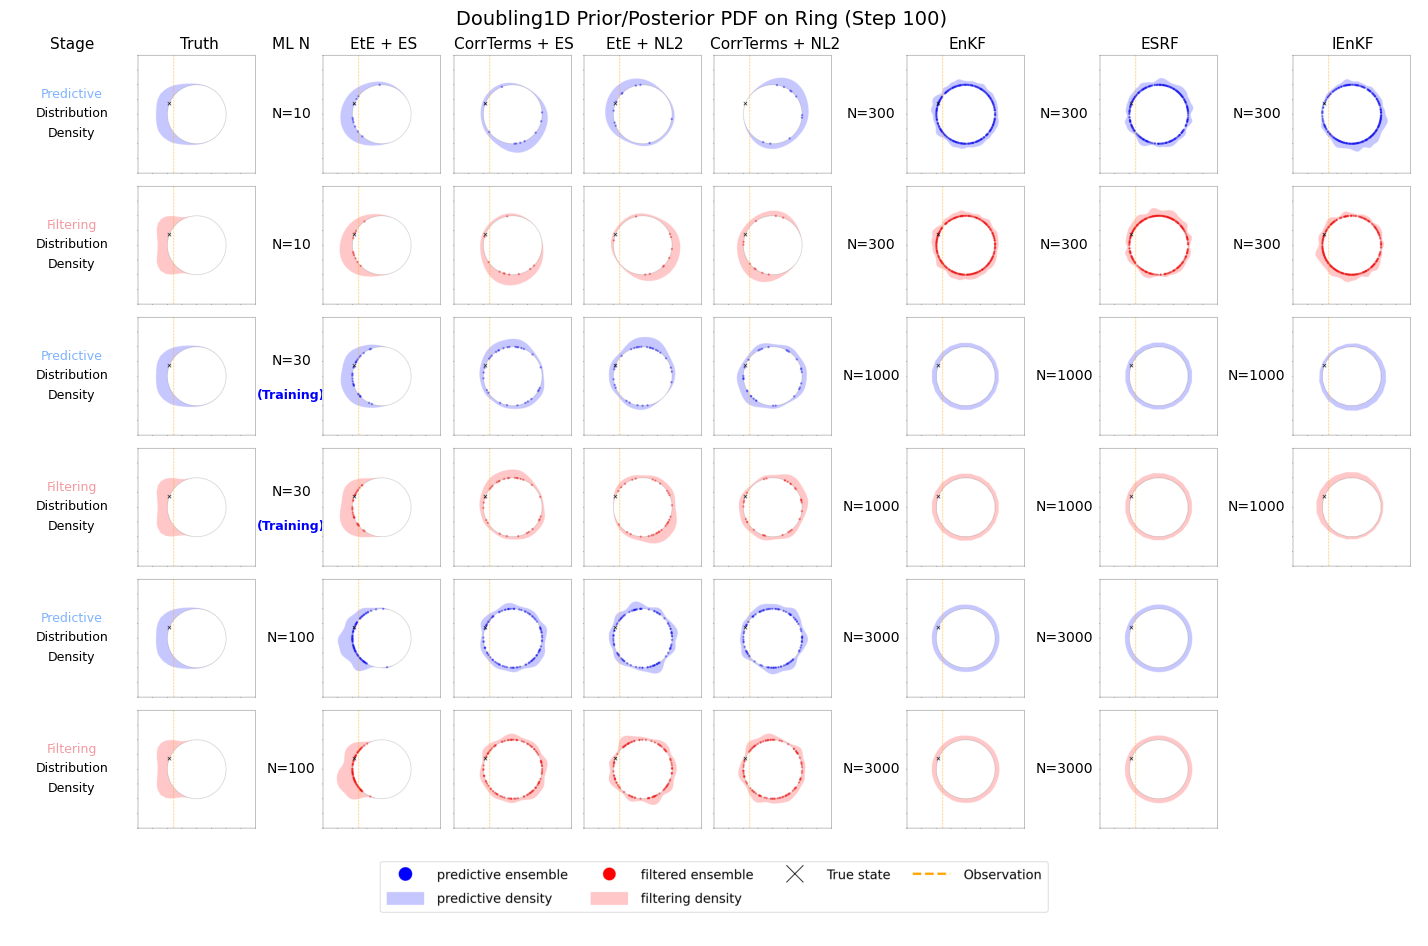

Saved prior/posterior combined grid image to: save/doubling1d_results/doubling1d_results_grid_step150_prior_posterior_with_benchmarks_and_legend.png


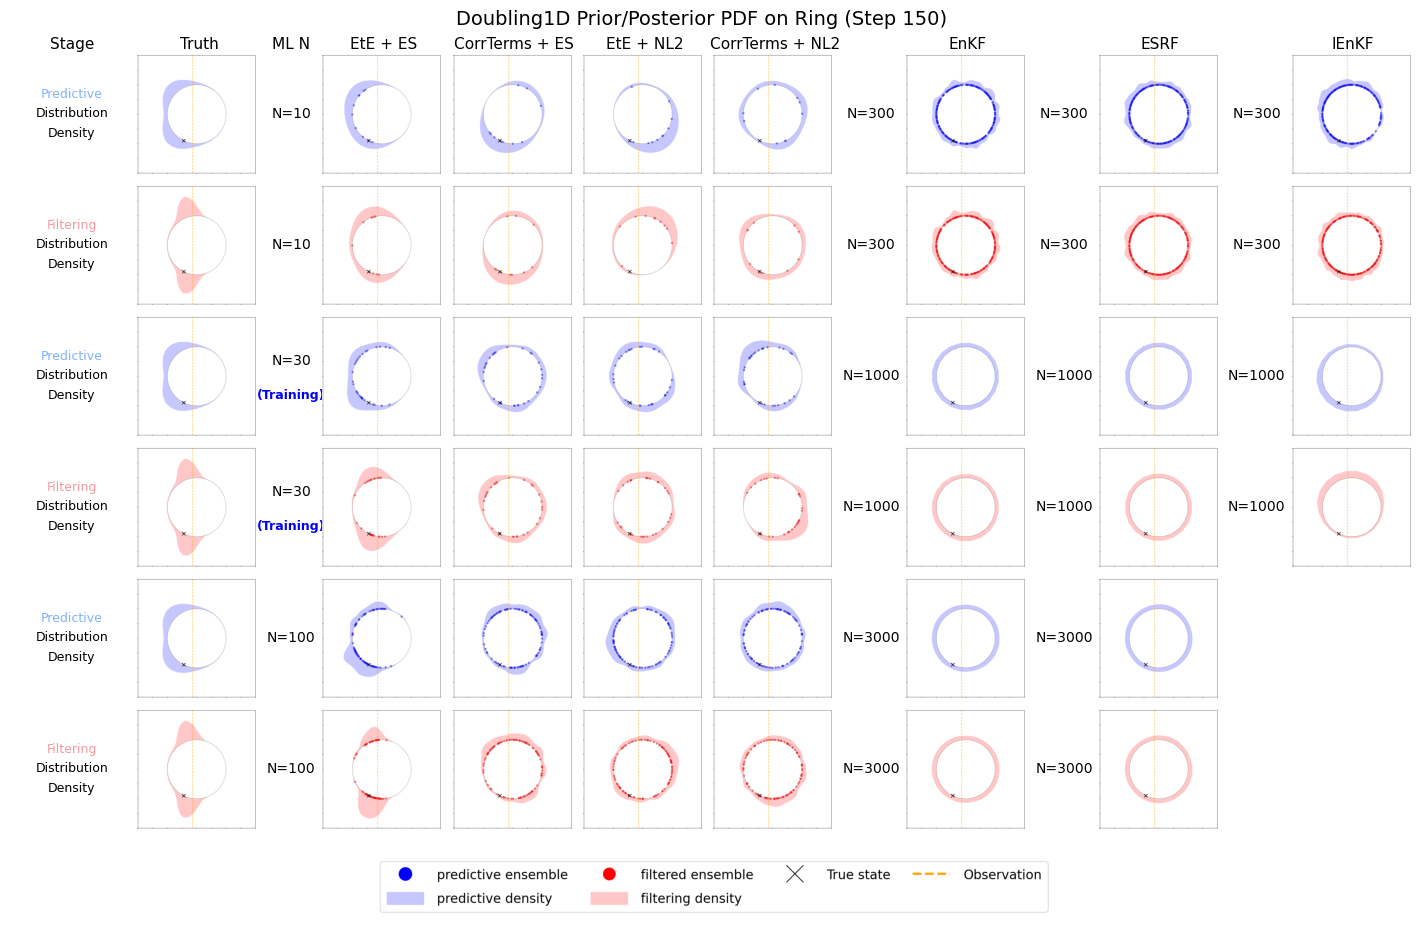

Saved prior/posterior combined grid image to: save/doubling1d_results/doubling1d_results_grid_step200_prior_posterior_with_benchmarks_and_legend.png


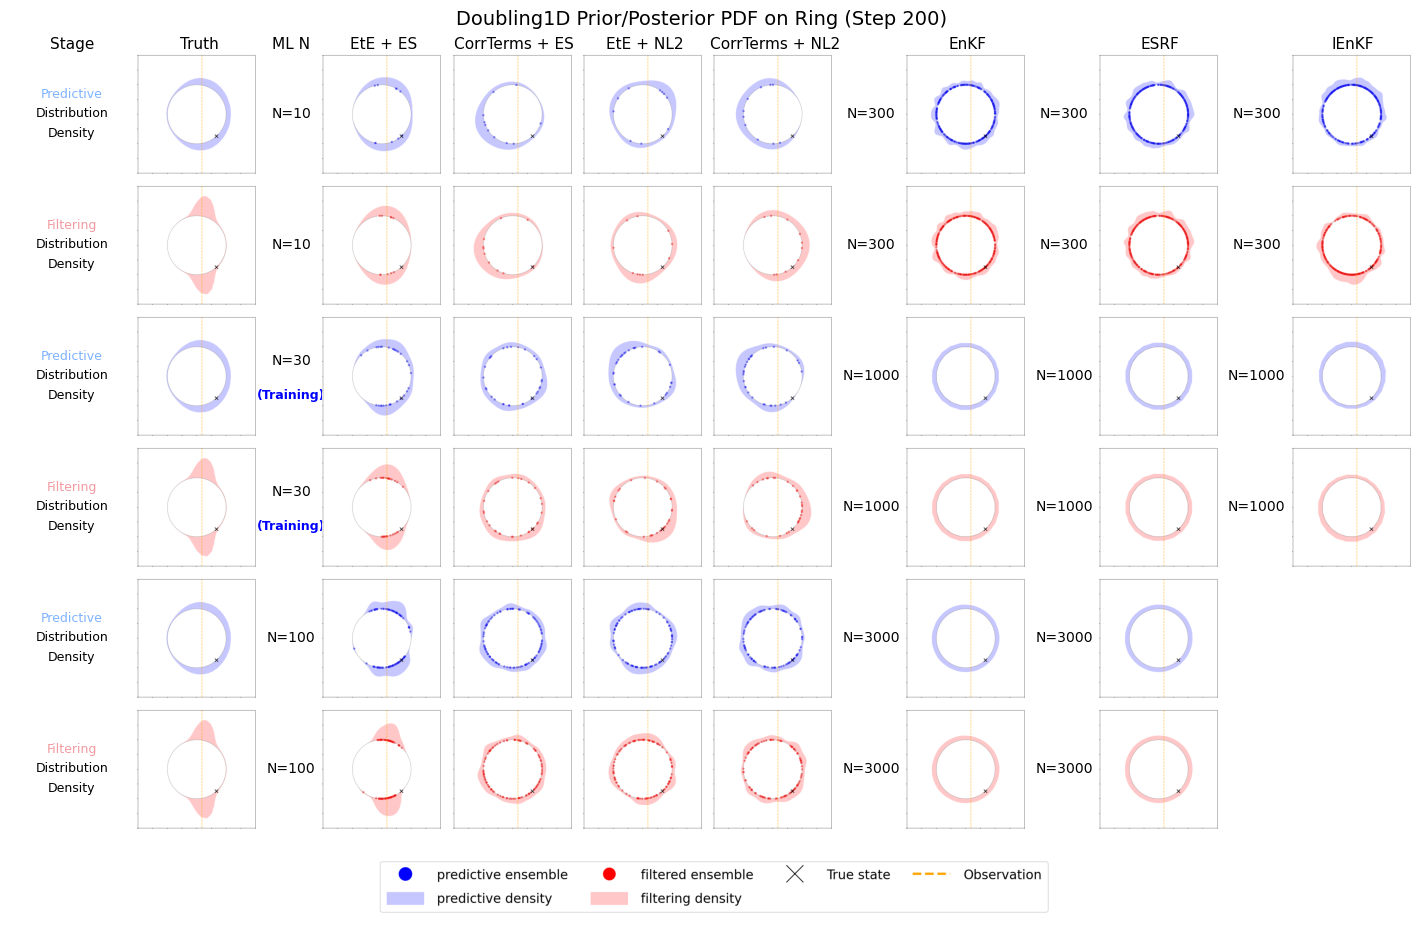

In [83]:
from pathlib import Path
import matplotlib.pyplot as plt

base_dir = Path('save/doubling1d_results')
enkf_dir = Path('save/benchmark_doubling1d_0.2_EnKF')
legend_path = enkf_dir / 'prior_post_density_combined_legend.png'
truth_dir = Path('save/doubling1d_pf_vis')

methods = [
    ('EtE + ES', '2026-02-12_19-24doubling1d_0.2_30_60_8192_es_joint_EtE-LResNone_cos2pi'),
    ('CorrTerms + ES', '2026-02-12_19-24doubling1d_0.2_30_60_8192_es_joint_CorrTermsNone_cos2pi'),
    ('EtE + NL2', '2026-02-12_19-24doubling1d_0.2_30_60_8192_nl2_joint_EtE-LResNone_cos2pi'),
    ('CorrTerms + NL2', '2026-02-12_19-24doubling1d_0.2_30_60_8192_nl2_joint_CorrTermsNone_cos2pi'),
]
benchmark_methods = [
    ('EnKF', Path('save/benchmark_doubling1d_0.2_EnKF')),
    ('ESRF', Path('save/benchmark_doubling1d_0.2_ESRF')),
    ('IEnKF', Path('save/benchmark_doubling1d_0.2_iEnKS-PertObs')),
]

steps = [100, 150, 200]
ml_ensemble_sizes = [10, 30, 100]
benchmark_target_ensemble_sizes = [300, 1000, 3000]
seed = 0
row_stages = [
    ('Predictive\nDistribution\nDensity', 'prior', 'PRIOR'),
    ('Filtering\nDistribution\nDensity', 'post', 'POST'),
]

legend_crop = {
    'left': 0.0,
    'right': 0.0,
    'top': 0.2,
    'bottom': 0.2,
}
image_crop = {
    'left': 0.08,
    'right': 0.0,
    'top': 0.0,
    'bottom': 0.05,
}
legend_height_ratio = 0.8

if len(ml_ensemble_sizes) != len(benchmark_target_ensemble_sizes):
    raise ValueError('ML and benchmark target ensemble-size lists must have the same length.')

required_paths = [base_dir, truth_dir] + [benchmark_dir for _, benchmark_dir in benchmark_methods]
for required_path in required_paths:
    if not required_path.exists():
        raise FileNotFoundError(f'Missing required directory: {required_path}')

if not legend_path.exists():
    raise FileNotFoundError(f'Missing legend image: {legend_path}')


def get_available_ns(benchmark_dir):
    ns = []
    for path in benchmark_dir.glob('output_records_*.pt'):
        try:
            ns.append(int(path.stem.replace('output_records_', '')))
        except ValueError:
            continue
    if not ns:
        raise FileNotFoundError(f'No output_records_*.pt files found in {benchmark_dir}')
    return sorted(set(ns))


def resolve_benchmark_ns(available_ns, target_ns, allow_fallback):
    resolved = []
    for target in target_ns:
        if target in available_ns:
            resolved.append(target)
            continue
        if allow_fallback:
            smaller_or_equal = [n for n in available_ns if n <= target]
            if smaller_or_equal:
                resolved.append(max(smaller_or_equal))
            else:
                resolved.append(min(available_ns))
        else:
            resolved.append(None)
    return resolved


benchmark_ns_map = {}
for benchmark_label, benchmark_dir in benchmark_methods:
    available_ns = get_available_ns(benchmark_dir)
    allow_fallback = benchmark_label != 'IEnKF'
    resolved_ns = resolve_benchmark_ns(available_ns, benchmark_target_ensemble_sizes, allow_fallback)
    benchmark_ns_map[benchmark_label] = resolved_ns
    if allow_fallback and resolved_ns != benchmark_target_ensemble_sizes:
        print(
            f'{benchmark_label}: fallback benchmark N list {resolved_ns} '
            f'(target was {benchmark_target_ensemble_sizes}, available {available_ns})'
        )
    if not allow_fallback:
        missing_targets = [target for target, resolved in zip(benchmark_target_ensemble_sizes, resolved_ns) if resolved is None]
        if missing_targets:
            print(f'{benchmark_label}: missing target N {missing_targets}, keep corresponding rows blank.')


def crop_image(image, crop):
    h, w = image.shape[:2]
    left = int(w * crop.get('left', 0.0))
    right = int(w * crop.get('right', 0.0))
    top = int(h * crop.get('top', 0.0))
    bottom = int(h * crop.get('bottom', 0.0))

    if left + right >= w:
        raise ValueError('Crop left+right ratio exceeds 1.0.')
    if top + bottom >= h:
        raise ValueError('Crop top+bottom ratio exceeds 1.0.')

    x_end = w - right if right > 0 else w
    y_end = h - bottom if bottom > 0 else h
    return image[top:y_end, left:x_end]


def get_truth_path(step, truth_tag):
    timestep = step - 1
    return truth_dir / (
        f'sigma_y0.2_batch64_len200_pfN1000000_timestep{timestep}_42_g0_{truth_tag}_0_ring_pdf_on_ring_nohist.png'
    )


def get_ml_path(method_folder, ml_n, step, stage_key):
    prefix = f'test_{ml_n}_{seed}'
    if stage_key == 'prior':
        prefix += '_prior'
    return base_dir / method_folder / f'{prefix}_g0_slice_step{step}_0_ring_pdf_on_ring_nohist.png'


def get_benchmark_path(benchmark_dir, benchmark_n, step, stage_key):
    stage_token = 'classic_prior' if stage_key == 'prior' else 'classic'
    return benchmark_dir / f'test_{benchmark_n}_0_{stage_token}_g0_slice_step{step}_0_ring_pdf_on_ring_nohist.png'


def save_grid_image(step, legend_img):
    truth_imgs = {}
    for stage_label, stage_key, truth_tag in row_stages:
        truth_path = get_truth_path(step, truth_tag)
        if not truth_path.exists():
            raise FileNotFoundError(f'Missing truth image for {stage_label.lower()} step {step}: {truth_path}')
        truth_imgs[stage_key] = crop_image(plt.imread(truth_path), image_crop)

    rows_per_n = len(row_stages)
    nrows = len(ml_ensemble_sizes) * rows_per_n

    col_stage = 0
    col_truth = 1
    col_ml_n = 2
    col_methods_start = 3
    col_benchmark_start = col_methods_start + len(methods)

    benchmark_width_ratios = []
    benchmark_titles = []
    for benchmark_label, _ in benchmark_methods:
        benchmark_width_ratios.extend([0.48, 1.0])
        benchmark_titles.extend(['', benchmark_label])

    ncols = col_benchmark_start + 2 * len(benchmark_methods)
    width_ratios = [0.95, 1.0, 0.42] + [1.0] * len(methods) + benchmark_width_ratios

    fig_height = 1.3 * nrows + 1.8
    fig = plt.figure(figsize=(14.4, fig_height))
    gs = fig.add_gridspec(
        nrows=nrows + 1,
        ncols=ncols,
        width_ratios=width_ratios,
        height_ratios=[1] * nrows + [legend_height_ratio],
    )
    axes = [[fig.add_subplot(gs[r, c]) for c in range(ncols)] for r in range(nrows)]

    column_titles = ['Stage', 'Truth', 'ML N'] + [m[0] for m in methods] + benchmark_titles
    for col, title in enumerate(column_titles):
        axes[0][col].set_title(title, fontsize=11, pad=3)

    missing = []
    for pair_idx, ml_n in enumerate(ml_ensemble_sizes):
        base_row = pair_idx * rows_per_n
        for stage_offset, (_, stage_key, _) in enumerate(row_stages):
            row = base_row + stage_offset

            ax_stage = axes[row][col_stage]
            ax_stage.axis('off')
            if stage_key == 'prior':
                ax_stage.text(0.5, 0.66, 'Predictive', ha='center', va='center', fontsize=9, color='#7fb3ff')
                ax_stage.text(0.5, 0.50, 'Distribution', ha='center', va='center', fontsize=9)
                ax_stage.text(0.5, 0.34, 'Density', ha='center', va='center', fontsize=9)
            else:
                ax_stage.text(0.5, 0.66, 'Filtering', ha='center', va='center', fontsize=9, color='#f29aa0')
                ax_stage.text(0.5, 0.50, 'Distribution', ha='center', va='center', fontsize=9)
                ax_stage.text(0.5, 0.34, 'Density', ha='center', va='center', fontsize=9)

            axes[row][col_truth].imshow(truth_imgs[stage_key])
            axes[row][col_truth].axis('off')

            ax_ml_n = axes[row][col_ml_n]
            ax_ml_n.axis('off')
            if ml_n == 30:
                ax_ml_n.text(0.5, 0.62, f'N={ml_n}', ha='center', va='center', fontsize=10)
                ax_ml_n.text(0.5, 0.34, '(Training)', ha='center', va='center', fontsize=9, color='blue', weight='bold')
            else:
                ax_ml_n.text(0.5, 0.5, f'N={ml_n}', ha='center', va='center', fontsize=10)

            for i, (_, method_folder) in enumerate(methods):
                col = col_methods_start + i
                ax = axes[row][col]
                image_path = get_ml_path(method_folder, ml_n, step, stage_key)
                if not image_path.exists():
                    missing.append(f'{stage_key} ML n={ml_n}: {image_path}')
                    ax.axis('off')
                    ax.text(0.5, 0.5, 'Missing', ha='center', va='center', fontsize=10)
                    continue
                ax.imshow(crop_image(plt.imread(image_path), image_crop))
                ax.axis('off')

            for benchmark_idx, (benchmark_label, benchmark_dir) in enumerate(benchmark_methods):
                benchmark_n = benchmark_ns_map[benchmark_label][pair_idx]
                col_benchmark_n = col_benchmark_start + 2 * benchmark_idx
                col_benchmark_img = col_benchmark_n + 1

                ax_benchmark_n = axes[row][col_benchmark_n]
                ax_benchmark = axes[row][col_benchmark_img]
                ax_benchmark_n.axis('off')
                ax_benchmark.axis('off')

                if benchmark_n is None:
                    continue

                ax_benchmark_n.text(0.5, 0.5, f'N={benchmark_n}', ha='center', va='center', fontsize=10)

                benchmark_path = get_benchmark_path(benchmark_dir, benchmark_n, step, stage_key)
                if not benchmark_path.exists():
                    missing.append(f'{stage_key} {benchmark_label} n={benchmark_n}: {benchmark_path}')
                    ax_benchmark.text(0.5, 0.5, 'Missing', ha='center', va='center', fontsize=10)
                else:
                    ax_benchmark.imshow(crop_image(plt.imread(benchmark_path), image_crop))
                    ax_benchmark.axis('off')

    if missing:
        raise FileNotFoundError(
            f'Some expected images were not found for step {step}:\n' + '\n'.join(missing)
        )

    legend_ax = fig.add_subplot(gs[nrows, :])
    legend_ax.imshow(legend_img, aspect='equal')
    legend_ax.axis('off')

    fig.suptitle(f'Doubling1D Prior/Posterior PDF on Ring (Step {step})', fontsize=14, y=0.995)
    fig.subplots_adjust(left=0.02, right=0.998, top=0.95, bottom=0.03, wspace=0.0, hspace=0.08)

    output_path = base_dir / f'doubling1d_results_grid_step{step}_prior_posterior_with_benchmarks_and_legend.png'
    fig.savefig(output_path, dpi=260, bbox_inches='tight', pad_inches=0.02)
    print(f'Saved prior/posterior combined grid image to: {output_path}')
    plt.show()


legend_img = crop_image(plt.imread(legend_path), legend_crop)

for step in steps:
    save_grid_image(step, legend_img)





/tmp/ipykernel_200767/4192344731.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  payload = torch.load(path, map_location='cpu')


Saved metric figure to: save/doubling1d_results/doubling1d_pf_sed_vs_N.png


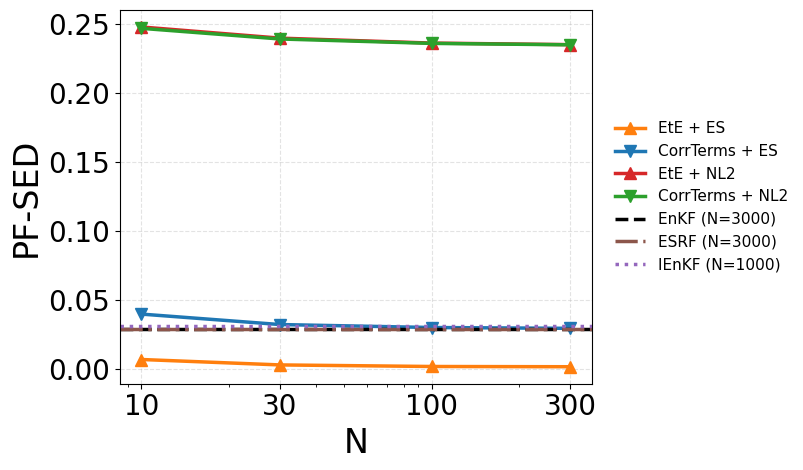

Saved metric figure to: save/doubling1d_results/doubling1d_es1_vs_N.png


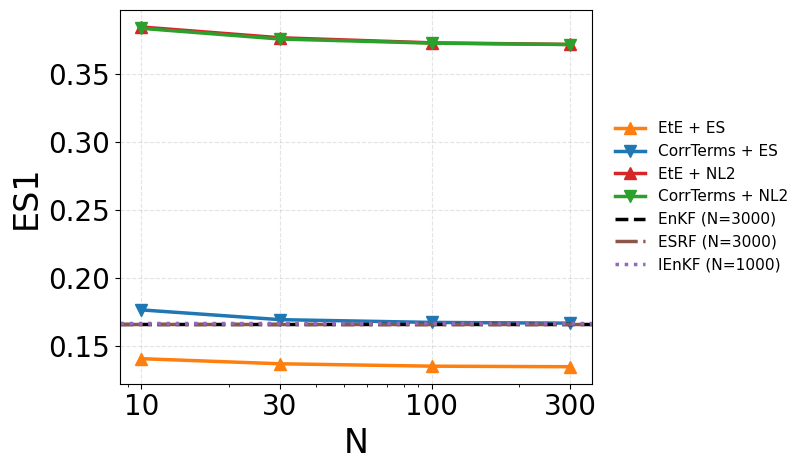

Saved metric figure to: save/doubling1d_results/doubling1d_rank_hist_freqvar_vs_N.png


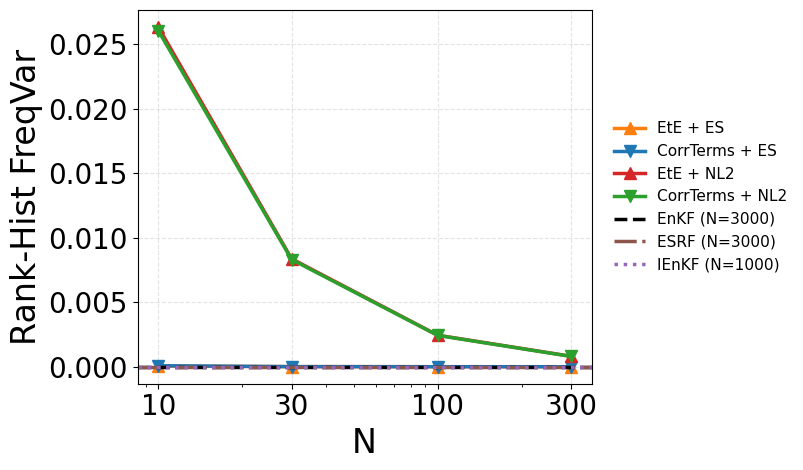

Saved legend figure to: save/doubling1d_results/doubling1d_metrics_vs_N_legend_horizontal.png


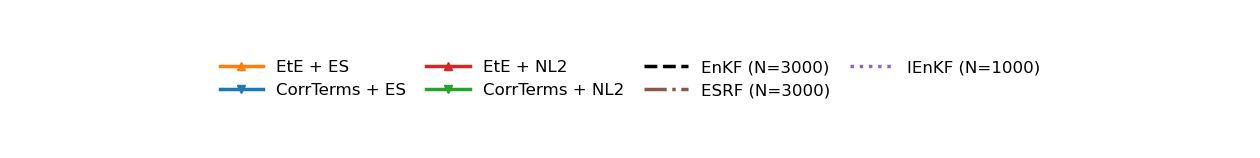

In [84]:
from pathlib import Path
import math
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import torch

base_dir = Path('save/doubling1d_results')
benchmark_dirs = {
    'EnKF': Path('save/benchmark_doubling1d_0.2_EnKF'),
    'ESRF': Path('save/benchmark_doubling1d_0.2_ESRF'),
    'IEnKF': Path('save/benchmark_doubling1d_0.2_iEnKS-PertObs'),
}

methods = [
    ('EtE + ES', '2026-02-12_19-24doubling1d_0.2_30_60_8192_es_joint_EtE-LResNone_cos2pi'),
    ('CorrTerms + ES', '2026-02-12_19-24doubling1d_0.2_30_60_8192_es_joint_CorrTermsNone_cos2pi'),
    ('EtE + NL2', '2026-02-12_19-24doubling1d_0.2_30_60_8192_nl2_joint_EtE-LResNone_cos2pi'),
    ('CorrTerms + NL2', '2026-02-12_19-24doubling1d_0.2_30_60_8192_nl2_joint_CorrTermsNone_cos2pi'),
]

metric_specs = [
    ('PF-SED', ('mean_pf_sed', 'pf_sed'), 'pf_sed'),
    ('ES1', ('mean_es1', 'es1'), 'es1'),
    ('Rank-Hist FreqVar', ('rank_freq_var',), 'rank_hist_freqvar'),
]

selected_ns = [10, 30, 100, 300]
axis_label_fontsize = 24
tick_fontsize = 20

# Width for saved figure (without legend).
fig_width_no_legend = 4
# Display figure uses extra width to fit legend on the right.
fig_width_with_legend = fig_width_no_legend + 6
fig_height = 4.8

series_styles = {
    'CorrTerms + ES': {'color': '#1f77b4', 'marker': 'v', 'linestyle': '-', 'x_factor': 1.0},
    'EtE + ES': {'color': '#ff7f0e', 'marker': '^', 'linestyle': '-', 'x_factor': 1.0},
    'CorrTerms + NL2': {'color': '#2ca02c', 'marker': 'v', 'linestyle': '-', 'x_factor': 1.0},
    'EtE + NL2': {'color': '#d62728', 'marker': '^', 'linestyle': '-', 'x_factor': 1.0},
}
benchmark_styles = {
    'EnKF': {'color': 'black', 'linestyle': '--'},
    'ESRF': {'color': '#8c564b', 'linestyle': '-.'},
    'IEnKF': {'color': '#9467bd', 'linestyle': ':'},
}


def extract_metric(payload, candidate_keys):
    metric_sources = [payload.get('nn', {}), payload.get('test_results', {})]
    for key in candidate_keys:
        for source in metric_sources:
            if key in source:
                return float(source[key])
    return float('nan')


def collect_metric_series(folder):
    records = []
    for path in sorted(folder.glob('output_records_*.pt')):
        n_str = path.stem.replace('output_records_', '')
        try:
            ensemble_size = int(n_str)
        except ValueError:
            continue

        payload = torch.load(path, map_location='cpu')
        row = {'N': ensemble_size}
        for metric_label, candidate_keys, _ in metric_specs:
            row[metric_label] = extract_metric(payload, candidate_keys)
        records.append(row)

    if not records:
        raise FileNotFoundError(f'No output_records_*.pt files found in {folder}')

    records.sort(key=lambda row: row['N'])
    return records


def draw_metric(ax, metric_label):
    for series_label, _ in methods:
        rows = series_map[series_label]
        style = series_styles[series_label]
        valid_points = [
            (row['N'] * style['x_factor'], row[metric_label])
            for row in rows
            if row['N'] in selected_ns and math.isfinite(row[metric_label])
        ]
        if not valid_points:
            continue

        xs, ys = zip(*valid_points)
        ax.plot(
            xs,
            ys,
            marker=style['marker'],
            linestyle=style['linestyle'],
            linewidth=2.5,
            markersize=8,
            color=style['color'],
            label=series_label,
        )

    for benchmark_label, reference_row in benchmark_reference_rows.items():
        benchmark_value = reference_row[metric_label]
        if math.isfinite(benchmark_value):
            style = benchmark_styles[benchmark_label]
            ax.axhline(
                benchmark_value,
                linewidth=2.5,
                linestyle=style['linestyle'],
                color=style['color'],
                label=f"{benchmark_label} (N={reference_row['N']})",
            )

    ax.set_xlabel('N', fontsize=axis_label_fontsize)
    ax.set_ylabel(metric_label, fontsize=axis_label_fontsize)
    ax.set_xscale('log')
    ax.set_xticks(selected_ns)
    ax.get_xaxis().set_major_formatter(ScalarFormatter())
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.grid(True, linestyle='--', alpha=0.35)


series_map = {
    label: collect_metric_series(base_dir / folder_name)
    for label, folder_name in methods
}
benchmark_series_map = {
    benchmark_label: collect_metric_series(benchmark_dir)
    for benchmark_label, benchmark_dir in benchmark_dirs.items()
}
benchmark_reference_rows = {
    benchmark_label: max(rows, key=lambda row: row['N'])
    for benchmark_label, rows in benchmark_series_map.items()
}

ml_legend_labels = [label for label, _ in methods]
ml_legend_handles = [
    Line2D([0], [0], linewidth=2.5, marker=series_styles[label]['marker'], linestyle=series_styles[label]['linestyle'], color=series_styles[label]['color'])
    for label, _ in methods
]
benchmark_legend_labels = [
    f"{benchmark_label} (N={benchmark_reference_rows[benchmark_label]['N']})"
    for benchmark_label in benchmark_dirs
]
benchmark_legend_handles = [
    Line2D([0], [0], linewidth=2.5, linestyle=benchmark_styles[benchmark_label]['linestyle'], color=benchmark_styles[benchmark_label]['color'])
    for benchmark_label in benchmark_dirs
]

for metric_label, _, metric_key in metric_specs:
    # 1) Save a narrow figure without legend, and do not display it.
    fig_save, ax_save = plt.subplots(figsize=(fig_width_no_legend, fig_height))
    draw_metric(ax_save, metric_label)
    fig_save.tight_layout()
    output_path = base_dir / f'doubling1d_{metric_key}_vs_N.png'
    fig_save.savefig(output_path, dpi=220, bbox_inches='tight')
    print(f'Saved metric figure to: {output_path}')
    plt.close(fig_save)

    # 2) Show a wider figure with legend on the right, and do not save it.
    fig_show, ax_show = plt.subplots(figsize=(fig_width_with_legend, fig_height))
    draw_metric(ax_show, metric_label)
    ax_show.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=11)
    fig_show.tight_layout(rect=(0, 0, 0.82, 1))
    plt.show()


legend_labels = ml_legend_labels + benchmark_legend_labels
legend_handles = ml_legend_handles + benchmark_legend_handles

legend_fig, legend_ax = plt.subplots(figsize=(16, 1.8))
legend_ax.axis('off')
legend_ax.legend(
    legend_handles,
    legend_labels,
    loc='center',
    ncol=4,
    frameon=False,
    handlelength=2.6,
    columnspacing=1.2,
    fontsize=12,
)

legend_output_path = base_dir / 'doubling1d_metrics_vs_N_legend_horizontal.png'
legend_fig.savefig(legend_output_path, dpi=220, bbox_inches='tight', pad_inches=0.06)
print(f'Saved legend figure to: {legend_output_path}')
plt.show()





sliced energy distance = $\int (F(x) - F^*(x))^2 dx$, $F(x)$ is the CDF